In [1]:
####   Libraries  ####

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim import lr_scheduler
from torch.autograd import Variable
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data.sampler import SubsetRandomSampler

from tqdm import tqdm

from torch.utils.data import DataLoader
from typing import Optional, Callable, Union, Iterable, List, Any, Dict, Tuple
from torch import Tensor
from torch.optim.optimizer import Optimizer
import torchvision.transforms.functional as TF
import random
from torchmetrics import StructuralSimilarityIndexMeasure
from torchmetrics import PeakSignalNoiseRatio



#print("PyTorch Version: ",torch.__version__)   # Be sure about having pytorch properly!
#print("Torchvision Version: ",torchvision.__version__)f the current session

In [2]:
# Transformations to augment dataset

train_transforms = transforms.Compose([                                      
                                       #transforms.GaussianBlur(kernel_size=3, sigma=0.05), 
                                       transforms.RandomHorizontalFlip(),
                                       transforms.RandomVerticalFlip(),        
                                       transforms.RandomAutocontrast(),
                                       transforms.ToTensor()
                                       ])
    
test_transforms = transforms.Compose([                                      
                                       transforms.ToTensor()
                                       ])

In [3]:
data_dir= '../input/dcmndataset/ground_truth'
train_data = datasets.ImageFolder(data_dir + '/train', transform=train_transforms)
test_data = datasets.ImageFolder(data_dir + '/test', transform=test_transforms)

# number of subprocesses to use for data loading
num_workers = 2

# how many samples per batch to load
batch_size = 20

# percentage of training set to use as validation
valid_size = 0.01

num_train = len(train_data)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(valid_size * num_train))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches

train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)   


# prepare data loaders (combine dataset and sampler)

train_loader = DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
#valid_loader = DataLoader(train_data, batch_size=batch_size, 
#    sampler=valid_sampler, num_workers=num_workers)
test_loader = DataLoader(test_data, batch_size=batch_size, 
    num_workers=num_workers)

In [4]:
def imshow(img): # display an image
    plt.imshow(np.transpose(img, (1, 2, 0))) 

In [5]:
def microendoscopic_images(train_loader): # demonstrates the ground truth microendoscopic images 
  
  num_imgs = 10
    
  #obtain one batch of training images
  images, labels = next(iter(train_loader))
  images = images.numpy() # convert images to numpy for display

  # plot the images in the batch, along with the corresponding labels
  fig = plt.figure(figsize=(30, 10))

  # display num_imgs
  for idx in np.arange(num_imgs):
    ax = fig.add_subplot(2, int(num_imgs/2), idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(f'Image {labels[idx].numpy()}', fontsize=20, fontweight ='bold')
    
  # Load the next batch
  batch_images, batch_labels = next(iter(train_loader))


  # Display the first image from the batch
  plt.imshow(np.transpose(batch_images[0], (1, 2, 0)))
  plt.suptitle('Microendoscopic Images', fontsize=25, fontweight ='bold')
  plt.show()

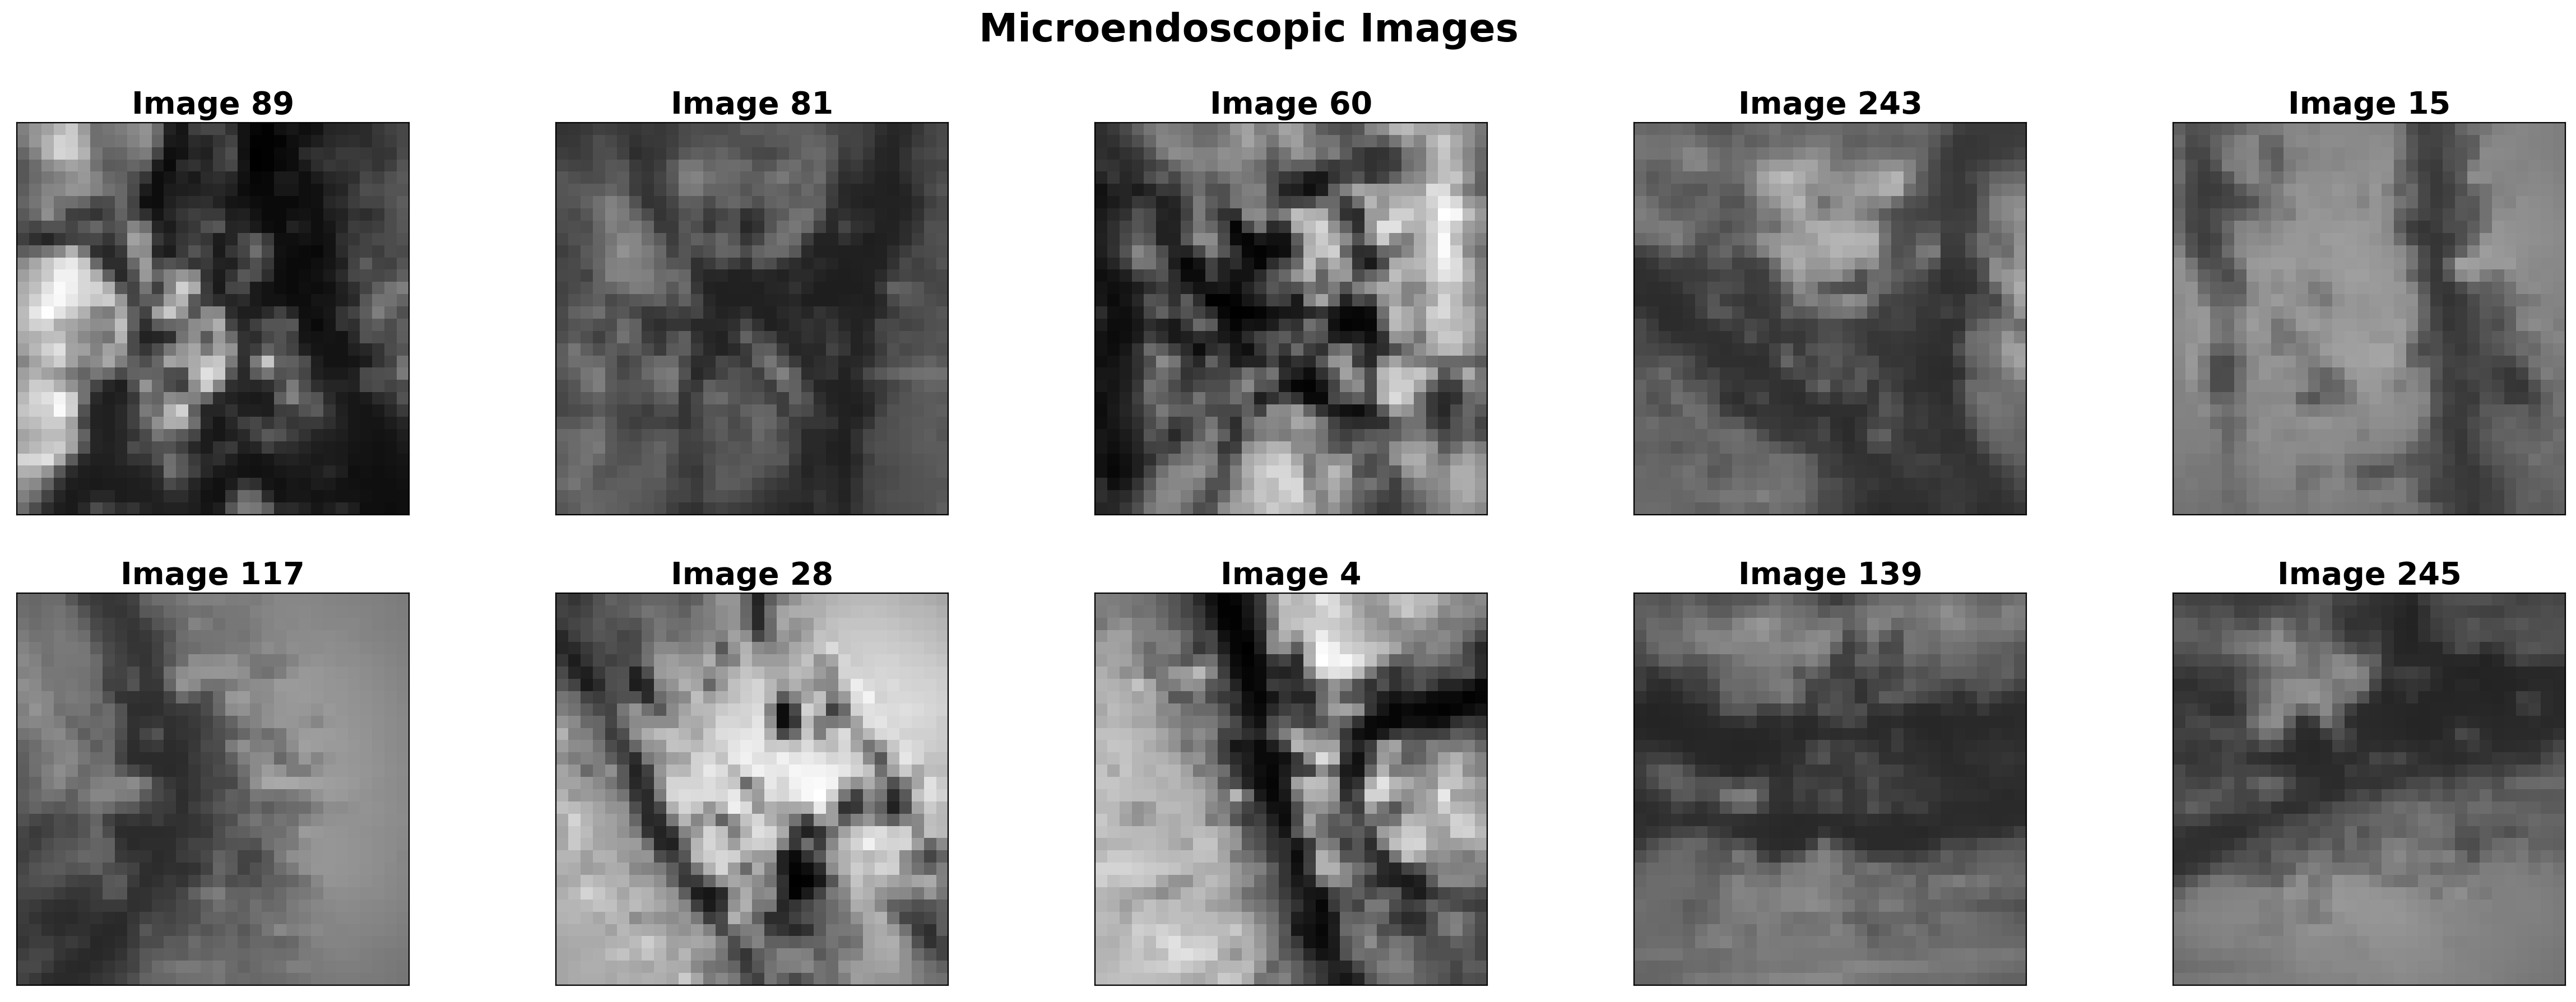

In [6]:
microendoscopic_images(train_loader)

In [7]:
class BaseModel(nn.Module):
  def __init__(self):
    super().__init__()

    # batch_size, 3, 32, 32
    self.encoder = None
    
    # N, 64, 1, 1
    self.decoder = None
    
  def forward(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded  

class DCMN(BaseModel):
  def __init__(self):
    super().__init__()

    # batch_size, 3, 32, 32
    self.encoder = nn.Sequential(
        nn.Conv2d(3, 16, # output channel
                  3, stride=2, padding=1), # N, 16, 16, 16

        nn.ReLU(),
        nn.Conv2d(16, 32, 3, stride=2, padding=1), # N, 32, 8, 8
        nn.ReLU(),
        nn.Conv2d(32, 64, 8), # N, 64, 3, 3
        ) 
    
    # N, 64, 1, 1
    self.decoder = nn.Sequential(
        nn.ConvTranspose2d(64, 32, 8), # N, 32, 7, 7
        nn.ReLU(),
        nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # N, 16, 16, 16
        nn.ReLU(),
        nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1), # N, 16, 32, 32
        nn.Sigmoid()
        ) 

In [8]:
# class BaseDecoder(nn.Module):
#   def __init__(self):
#     super().__init__()
    
#     # N, 64, 1, 1
#     self.decoder = nn.Sequential(
#         nn.ConvTranspose2d(64, 32, 8), # N, 32, 7, 7
#         nn.ReLU(),
#         nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # N, 16, 16, 16
#         nn.ReLU(),
#         nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1), # N, 16, 32, 32
#         nn.Sigmoid()
#     ) 
    
#   def forward(self, x):
#     return self.decoder(x)

In [9]:
def save_model(epochs, model, optimizer, criterion):
    """
    Function to save the trained model to disk.
    """
    torch.save({
                'epoch': epochs,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': criterion,
                }, './model.pth')

In [10]:
# TODO: create requirements.txt which contains all required packages.
!pip install piqa
# https://francois-rozet.github.io/piqa/piqa.html
# This package contains many similarity metrics like 
# ssim, fsim, psnr etc. thus, desired metrics could be 
# applied in the same way as a loss criterion.

from piqa import SSIM, PSNR

class SSIMLoss(SSIM):
    def forward(self, x, y):
        return 1. - super().forward(x, y)

class PSNRLoss(PSNR):
    def forward(self, x, y):
        return - super().forward(x, y)

def psnr_loss(x, y, **kwargs):
  return - psnr(x, y)

def ssim_loss(x, y, **kwargs):
  return 1 - ssim(x, y)

criterions_dict = {"ssim": SSIMLoss, "mse": nn.MSELoss, "psnr": PSNRLoss}
metrics_dict = {"ssim": SSIM().forward, "mse": nn.MSELoss().forward, "psnr": PSNR().forward}

In [11]:
def compare_images(ref_img, img):
    
  num_list = random.sample(range(len(ref_img)), 10)
  psnr = PeakSignalNoiseRatio()
  ssim = StructuralSimilarityIndexMeasure(data_range=1.0)
  f, axes = plt.subplots(2, 5, figsize=(30, 10))
  a = np.arange(0,10)

  for idx in range(5):
    axes[0,a[idx]].imshow(np.transpose(ref_img[num_list[idx]], (1, 2, 0)))
    axes[0,a[idx]].set_title(f'Image {idx+1}', fontsize=15, fontweight ='bold')
    axes[1,a[idx]].imshow(np.transpose(img[num_list[idx]], (1, 2, 0)))
    axes[1,a[idx]].set_title("PSNR: {0:.2f}, SSIM: {1:.2f}".format(
    psnr(torch.unsqueeze(ref_img[num_list[idx]], axis=0), torch.unsqueeze(img[num_list[idx]], axis=0)), 
    ssim(torch.unsqueeze(ref_img[num_list[idx]], axis=0), torch.unsqueeze(img[num_list[idx]], axis=0))), 
    fontweight='bold')
  plt.suptitle('Inference Results of Test Images', fontsize=25, fontweight ='bold')
  plt.show()

In [12]:
def inference_results(outputs):
  for img, output in outputs:
    compare_images(img, output.detach().cpu())

In [13]:
CriterionType = Callable[[Tensor, Tensor], Tensor]

def evaluate(model: BaseModel, 
             data_loader: DataLoader, 
             device: torch.device,
             criterion: CriterionType, 
             optimizer: Optional[Optimizer] = None,
             num_epochs: int = 1,
             metrics_fn: Optional[Dict[str, CriterionType]] = None,
             train_mode: bool = False) -> List[Any]:
             
    """This function starts training/testing with the given 
    parameters.

    Parameters
    ----------
    model : DCMN
      The (encoder/decoder) network that training is made.
    data_loader: DataLoader
      Contains test/train/val data.
    device: torch.device
      Indicates the runtime type (cuda vs. CPU).
    criterion: Callable[[Tensor, Tensor], Tensor]
      A criterion function that measures loss between ground truth and output.
    optimizer: Optional[Optimizer] 
      The optimizer that training is made.
    num_epochs: int
      Number of epochs.
    metrics_fn: Optional[Dict[str, CriterionType]]
      List of metric functions.
    train_mode: bool
      Indicates the current mode of the evaluation (i.e. test or train) by 
      default True.

    Returns
    -------
    List[Any]
      Resultant information (output image, epoch number, metrics etc.).

    """
    model.train(mode=train_mode)
    outputs = []
         
    for epoch in range(num_epochs):
      with tqdm(data_loader, unit="batch") as tepoch:
        for image, target in tepoch:
          tepoch.set_description(f"Epoch {epoch}")

        # for (image, _) in data_loader:
          img = image.to(device)

          # forward pass
          recon = model(img)
          

          # calculate the loss
          loss = criterion(recon, img)
        
          if train_mode:
            optimizer.zero_grad()
            
            # backpropagation
            loss.backward()
            
            # update the optimizer parameters
            optimizer.step()
            tepoch.set_postfix(loss=loss.item())
            
          else:
            outputs.append((image, recon)) 
    
    return outputs

Epoch 0: 100%|██████████| 2/2 [00:00<00:00,  7.63batch/s]


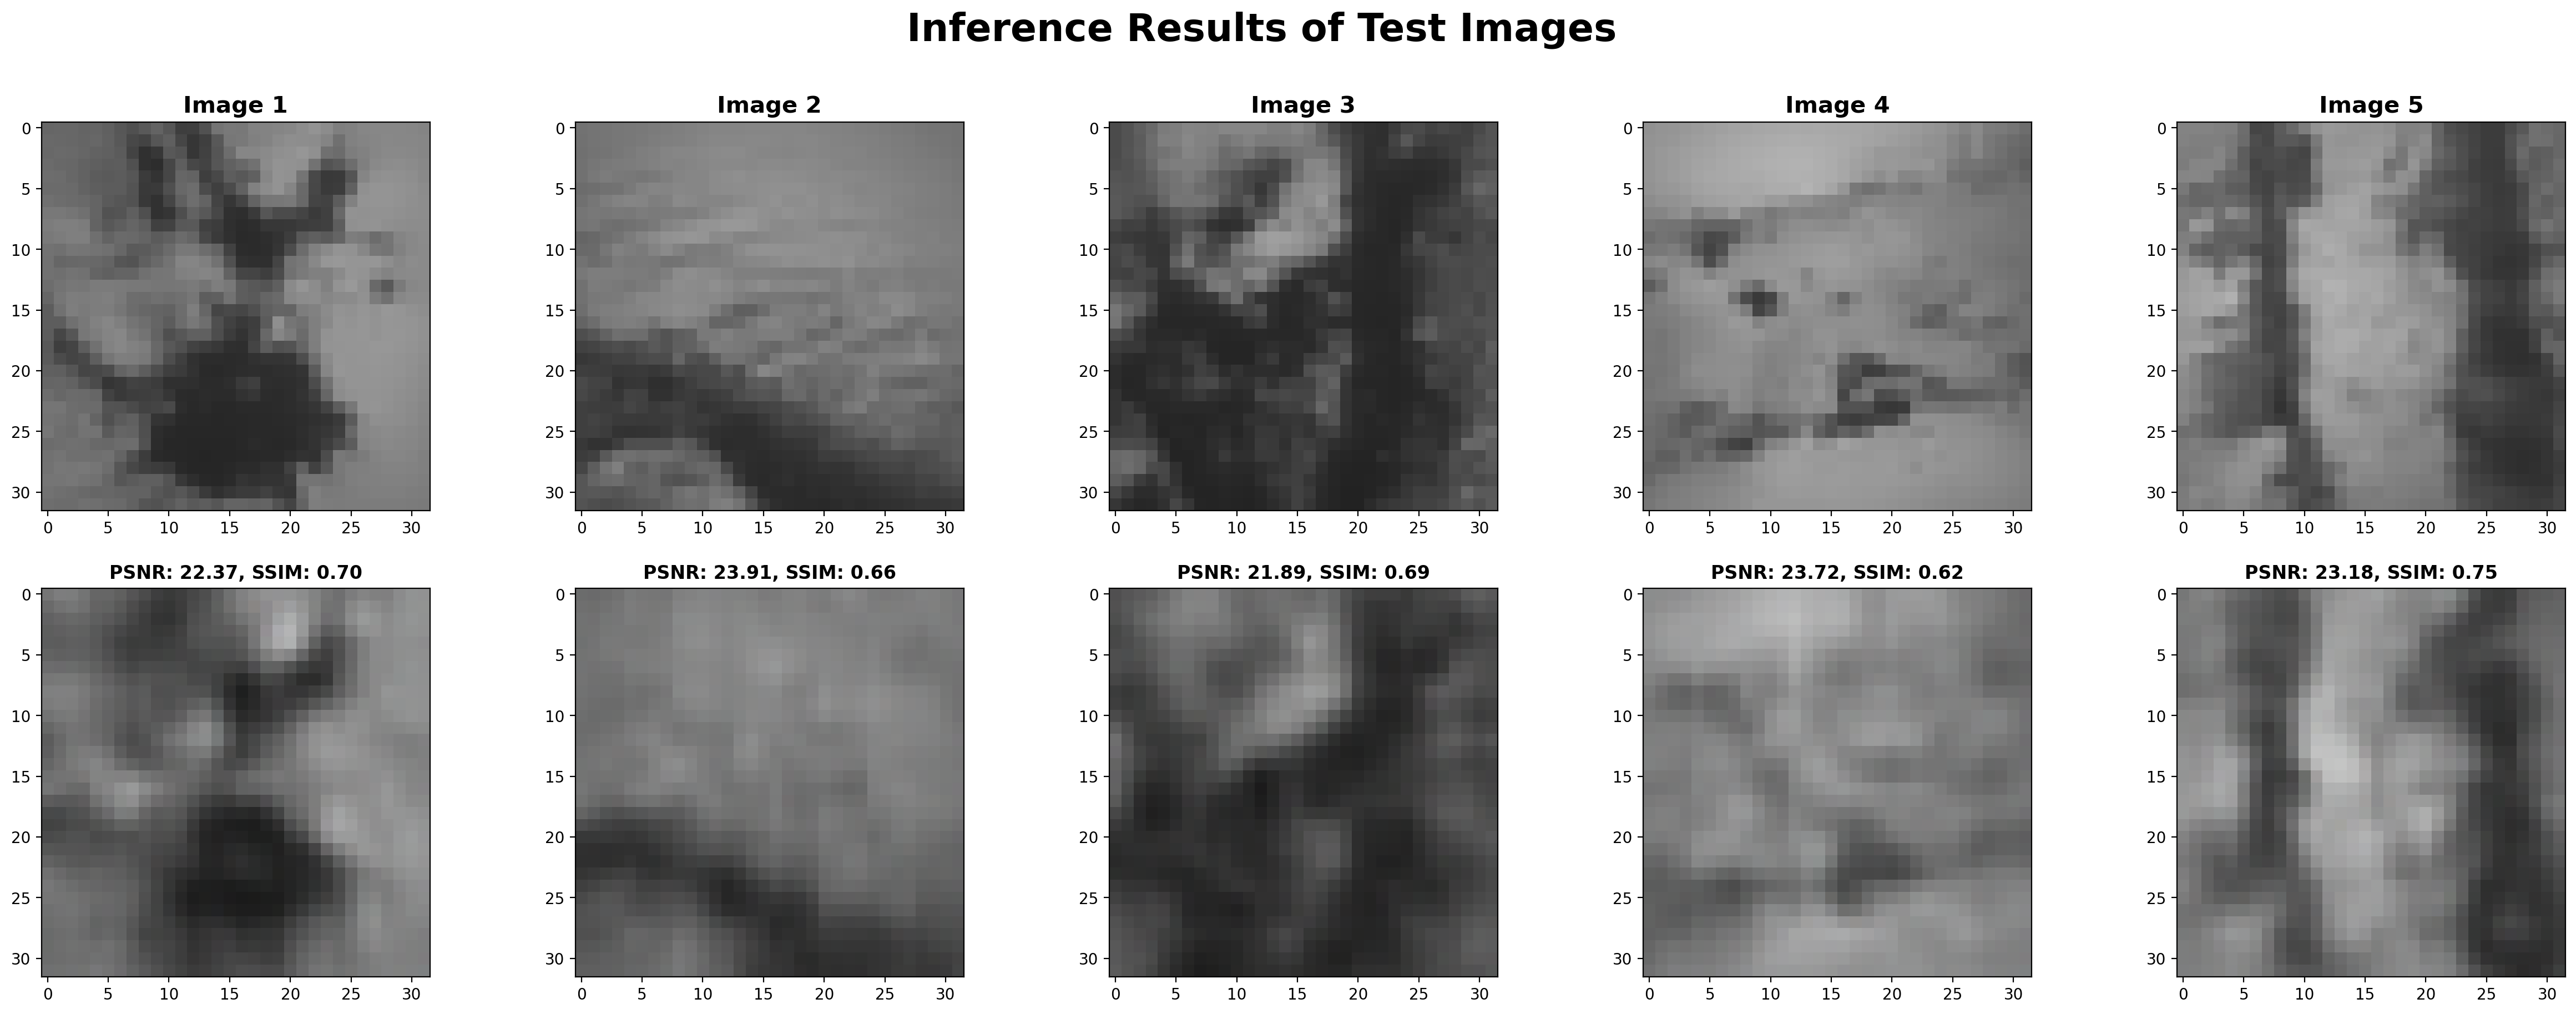

In [14]:
def main():

  device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  num_epochs = 280

  model = DCMN().to(device)
  criterion = criterions_dict["mse"]().to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3, weight_decay= 1e-6)
  metrics_fn = metrics_dict


  evaluate(
    model, train_loader, device, criterion, 
    optimizer, num_epochs, metrics_fn, True
  )
  
  # save the trained model weights
  #save_model(num_epochs, model, optimizer, criterion)


  # results of test data

  test_outputs = evaluate(
     model=model, data_loader=test_loader, device=device, 
    criterion=criterion, metrics_fn=metrics_fn
  )
    
#   train_outputs = evaluate(
#      model=model, data_loader=train_loader, device=device, 
#     criterion=criterion, metrics_fn=metrics_fn
#   )
   
  inference_results(test_outputs[:1])

if __name__ == "__main__":
    main()